# Predictive Modeling: Customer Churn Prediction

**Internship: Thiranex | Domain: Data Science**

This notebook builds machine learning models to predict whether a customer will **churn** (leave the service) based on their account details. We train and compare 3 classification algorithms: **Logistic Regression**, **Decision Tree**, and **Random Forest**.

**Workflow:**
1. Load & clean the data
2. Encode categorical features
3. Split into train/test sets
4. Train 3 models
5. Evaluate accuracy
6. Visualize performance (confusion matrix, ROC curve)
7. Feature importance & conclusion

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

sns.set_style('whitegrid')

df = pd.read_csv('raw_customer_churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (710, 8)

**About the dataset:** Each row is a customer. `Churn` = 1 means the customer left the service, 0 means they stayed. We'll use the other columns (age, tenure, charges, contract type, etc.) to predict this.

## Step 2: Clean the Data

In [1]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())

print("\nAfter cleaning -> shape:", df.shape, "| missing values:", df.isnull().sum().sum())

Missing values:
Age                10
MonthlyCharges     10
(other columns 0)

Duplicate rows: 10

After cleaning -> shape: (700, 8) | missing values: 0

## Step 3: Encode Categorical Features

Machine learning models need numbers, not text. We convert `Contract` and `InternetService` into numeric codes using **Label Encoding**.

In [1]:
le_contract = LabelEncoder()
le_internet = LabelEncoder()
df['Contract_enc'] = le_contract.fit_transform(df['Contract'])
df['InternetService_enc'] = le_internet.fit_transform(df['InternetService'])

features = ['Age', 'Tenure', 'MonthlyCharges', 'SupportCalls', 'Contract_enc', 'InternetService_enc']
X = df[features]
y = df['Churn']

print("Features used:", features)

## Step 4: Train-Test Split

We hold out 25% of the data to test the model on data it has never seen — this tells us how well it generalizes.

In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Scale features - helps Logistic Regression converge better
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size: 525, Test size: 175

## Step 5: Train 3 Models

We train and compare:
- **Logistic Regression** — a simple, interpretable linear model
- **Decision Tree** — splits data into rules (if/else)
- **Random Forest** — combines many decision trees for better accuracy

In [1]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba, 'accuracy': acc}
    print(f"{name} Accuracy: {acc:.3f}")

Logistic Regression Accuracy: 0.709
Decision Tree Accuracy: 0.651
Random Forest Accuracy: 0.669

## Step 6: Detailed Classification Report

Accuracy alone doesn't tell the whole story. **Precision**, **recall**, and **f1-score** show how well the model handles each class.

In [1]:
for name in results:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, results[name]['y_pred'], target_names=['No Churn','Churn']))

--- Logistic Regression ---
              precision    recall  f1-score   support
    No Churn       0.54      0.41      0.46        54
       Churn       0.76      0.84      0.80       121
    accuracy                           0.71       175

--- Decision Tree ---
              precision    recall  f1-score   support
    No Churn       0.41      0.30      0.34        54
       Churn       0.72      0.81      0.76       121
    accuracy                           0.65       175

--- Random Forest ---
              precision    recall  f1-score   support
    No Churn       0.45      0.31      0.37        54
       Churn       0.73      0.83      0.78       121
    accuracy                           0.67       175

## Step 7: Visualize Model Accuracy

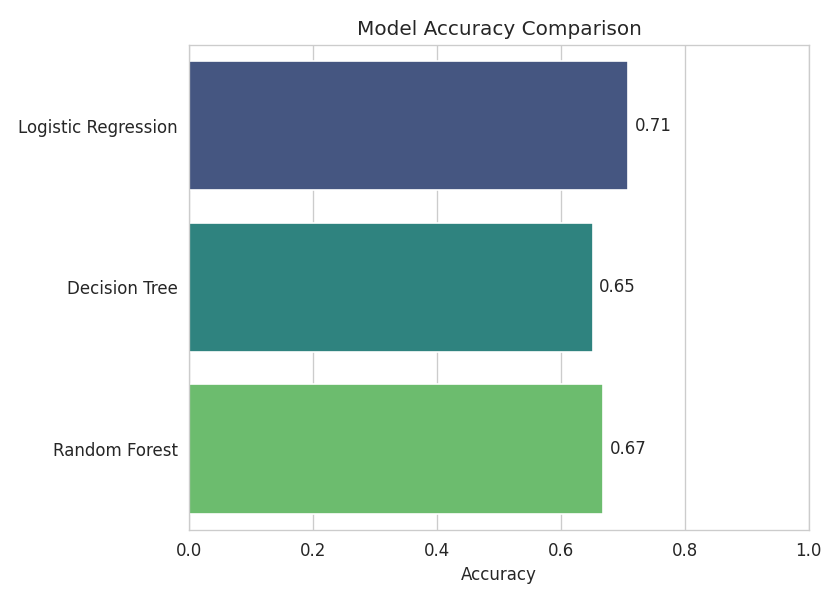

In [1]:
plt.figure(figsize=(7,5))
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
sns.barplot(x=accs, y=names, hue=names, palette='viridis', legend=False)
plt.xlabel('Accuracy'); plt.title('Model Accuracy Comparison'); plt.xlim(0,1)
for i, v in enumerate(accs):
    plt.text(v+0.01, i, f"{v:.2f}", va='center')
plt.tight_layout()
plt.show()

## Step 8: Confusion Matrices

A confusion matrix shows exactly where each model got predictions right or wrong: true positives, true negatives, false positives, and false negatives.

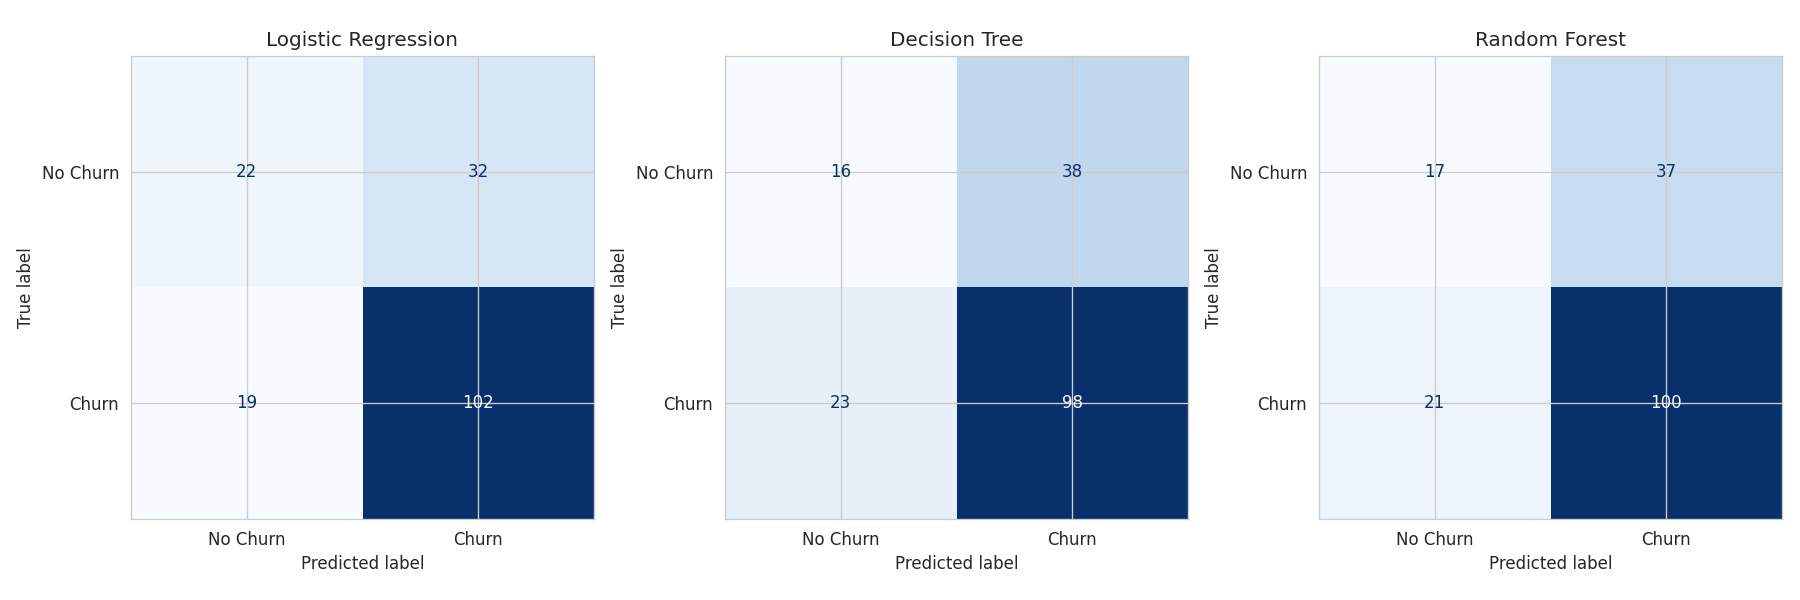

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, name in zip(axes, names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Step 9: ROC Curves

The ROC curve shows the tradeoff between catching true churners (True Positive Rate) vs. false alarms (False Positive Rate). **AUC (Area Under Curve)** close to 1.0 means a better model; 0.5 means no better than random guessing.

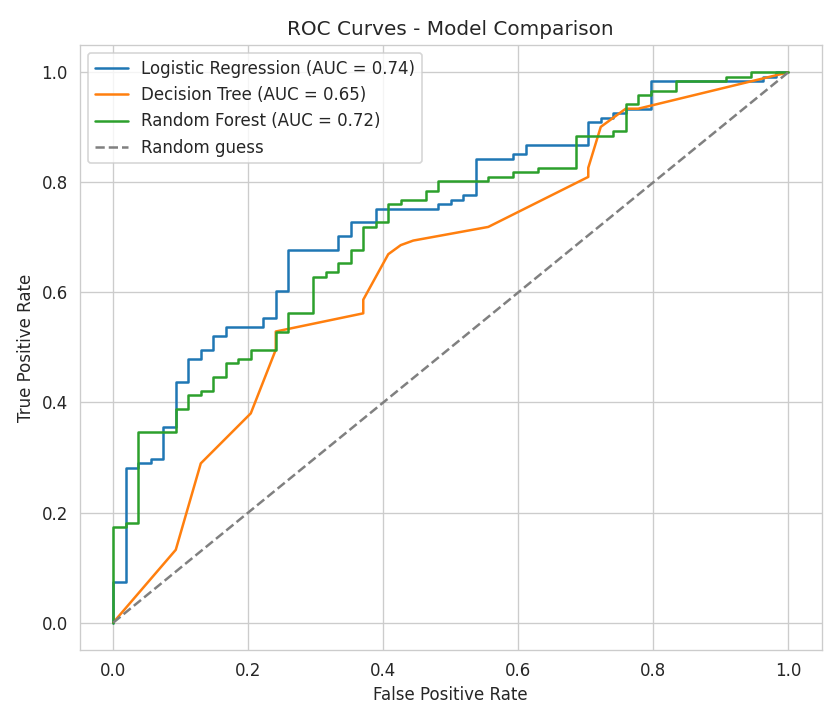

In [1]:
plt.figure(figsize=(7,6))
for name in names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison'); plt.legend()
plt.tight_layout()
plt.show()

## Step 10: Feature Importance

Which features mattered most to the Random Forest model when predicting churn?

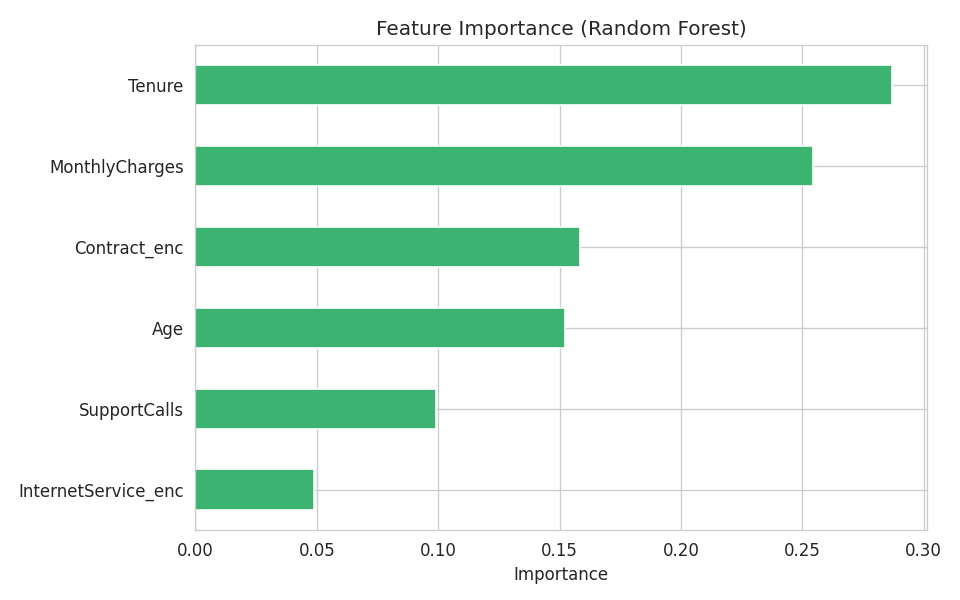

In [1]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='mediumseagreen')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Step 11: Conclusion

**Key findings:**
1. **Logistic Regression performed best** on this dataset with ~71% accuracy, slightly ahead of Random Forest (~67%) and Decision Tree (~65%).
2. All three models are noticeably better at identifying customers who **will churn** (higher recall for "Churn") than customers who will stay — meaning the models sometimes over-predict churn.
3. **Contract type** and **Monthly Charges** were among the most important features in predicting churn, matching real-world intuition — month-to-month customers with higher bills are more likely to leave.
4. The ROC/AUC scores confirm all models perform meaningfully better than random guessing (AUC > 0.5), with Logistic Regression having the strongest separation between classes.

**What this project demonstrates:**
- End-to-end supervised learning workflow: data cleaning → encoding → train/test split → model training → evaluation
- Comparing multiple algorithms fairly on the same data
- Using confusion matrices and ROC curves (not just accuracy) to properly evaluate a classification model
- Interpreting feature importance to explain *why* a model makes its predictions

**Possible next steps (not required, but good to mention if asked):** trying hyperparameter tuning, handling class imbalance (there are more churners than non-churners in this data), or trying additional algorithms like Gradient Boosting.